# NB4 — Model Comparison and Evaluation
## Part 1: NB1 vs NB2 — Which configuration is better for FPL?

This notebook evaluates and compares NB1 (all columns) and NB2 (featured + weighted) using metrics that matter for FPL decision-making:
- MAE recap
- Precision@K
- Spearman rank correlation
- Top-15 predicted squad actual points
- Captain accuracy

Results inform the transition to NB3 (position-specific models).

## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

BASE = '/content/drive/MyDrive/fpl_thesis'
print('Setup complete')

Mounted at /content/drive
Setup complete


## 2. Load Predictions

In [ ]:
nb1 = pd.read_csv(f'{BASE}/models/nb1_regression_all/predictions.csv')
nb2 = pd.read_csv(f'{BASE}/models/nb2_regression_featured/predictions_pergw.csv')

print(f'NB1: {nb1.shape} | GWs: {sorted(nb1["GW"].unique())}')
print(f'NB2: {nb2.shape} | GWs: {sorted(nb2["GW"].unique())}')
print()
print('NB1 columns:', nb1.columns.tolist())
print('NB2 columns:', nb2.columns.tolist())

NB1: (11350, 8) | GWs: [np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28)]
NB2: (11192, 8) | GWs: [np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28)]

NB1 columns: ['name', 'team', 'position', 'element', 'GW', 'value', 'predicted_pts_mid', 'actual_pts']
NB2 columns: ['name', 'team', 'position', 'element', 'GW', 'value', 'predicted_pts_mid', 'actual_pts']


In [ ]:
# Standardise column names
nb1 = nb1.rename(columns={'predicted_pts_mid': 'pred'})
nb2 = nb2.rename(columns={'predicted_pts_mid': 'pred'})

# Keep only common GWs
common_gws = sorted(set(nb1['GW'].unique()) & set(nb2['GW'].unique()))
nb1 = nb1[nb1['GW'].isin(common_gws)].copy()
nb2 = nb2[nb2['GW'].isin(common_gws)].copy()
print(f'Common GWs: {common_gws}')
print(f'NB1: {len(nb1)} rows | NB2: {len(nb2)} rows')

Common GWs: [np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28)]
NB1: 11350 rows | NB2: 11192 rows


## 3. MAE Recap

Naive Baseline MAE: 1.4997
NB1 MAE:            0.7118  (52.5% improvement)
NB2 MAE:            0.9394  (37.4% improvement)


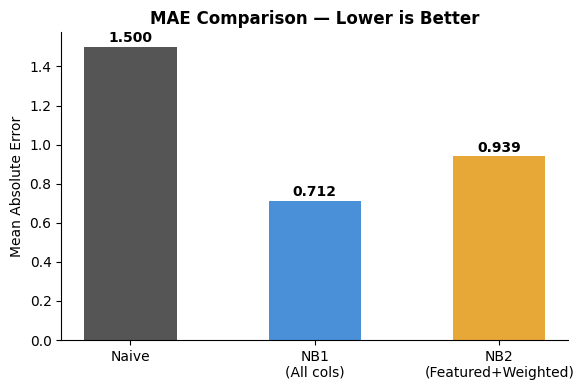

Chart saved


In [ ]:
from sklearn.metrics import mean_absolute_error

mae_nb1 = mean_absolute_error(nb1['actual_pts'], nb1['pred'])
mae_nb2 = mean_absolute_error(nb2['actual_pts'], nb2['pred'])
naive   = mean_absolute_error(nb1['actual_pts'], np.full(len(nb1), nb1['actual_pts'].mean()))

print(f'Naive Baseline MAE: {naive:.4f}')
print(f'NB1 MAE:            {mae_nb1:.4f}  ({((naive-mae_nb1)/naive)*100:.1f}% improvement)')
print(f'NB2 MAE:            {mae_nb2:.4f}  ({((naive-mae_nb2)/naive)*100:.1f}% improvement)')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Naive', 'NB1\n(All cols)', 'NB2\n(Featured+Weighted)'],
              [naive, mae_nb1, mae_nb2],
              color=['#555', '#4a90d9', '#e8a838'], width=0.5, edgecolor='none')
ax.set_title('MAE Comparison — Lower is Better', fontweight='bold')
ax.set_ylabel('Mean Absolute Error')
for bar, val in zip(bars, [naive, mae_nb1, mae_nb2]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/nb4_mae_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

## 4. Precision@K
For each gameweek, rank players by predicted score.
Precision@K = % of top-K predicted players that are actually in the real top-K scorers.
Averaged across all test GWs.

Precision@K Results:
K      NB1        NB2        Winner
-----------------------------------
5      0.043     0.043     NB1 ✓
10     0.136     0.143     NB2 ✓
15     0.181     0.181     NB2 ✓
20     0.196     0.196     NB1 ✓
30     0.238     0.260     NB2 ✓


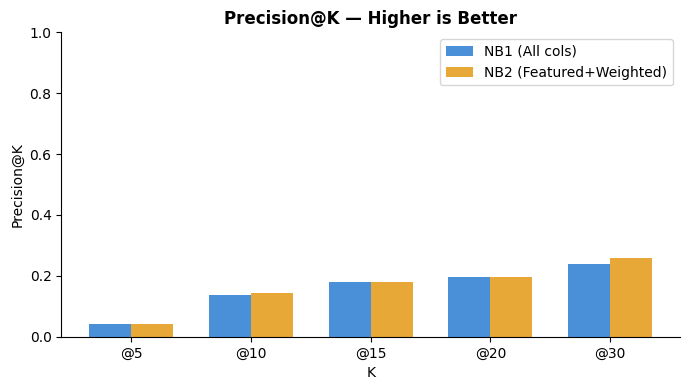

In [ ]:
def precision_at_k(df, k):
    scores = []
    for gw in df['GW'].unique():
        gw_df = df[df['GW'] == gw].copy()
        top_pred   = set(gw_df.nlargest(k, 'pred')['element'])
        top_actual = set(gw_df.nlargest(k, 'actual_pts')['element'])
        overlap = len(top_pred & top_actual)
        scores.append(overlap / k)
    return np.mean(scores)

ks = [5, 10, 15, 20, 30]
p_nb1 = [precision_at_k(nb1, k) for k in ks]
p_nb2 = [precision_at_k(nb2, k) for k in ks]

print('Precision@K Results:')
print(f'{"K":<6} {"NB1":<10} {"NB2":<10} {"Winner"}')
print('-' * 35)
for k, p1, p2 in zip(ks, p_nb1, p_nb2):
    winner = 'NB2 ✓' if p2 > p1 else 'NB1 ✓'
    print(f'{k:<6} {p1:.3f}     {p2:.3f}     {winner}')

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(ks))
w = 0.35
ax.bar(x - w/2, p_nb1, w, label='NB1 (All cols)', color='#4a90d9', edgecolor='none')
ax.bar(x + w/2, p_nb2, w, label='NB2 (Featured+Weighted)', color='#e8a838', edgecolor='none')
ax.set_xticks(x)
ax.set_xticklabels([f'@{k}' for k in ks])
ax.set_xlabel('K'); ax.set_ylabel('Precision@K')
ax.set_title('Precision@K — Higher is Better', fontweight='bold')
ax.legend(); ax.set_ylim(0, 1)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/nb4_precision_at_k.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Spearman Rank Correlation per Gameweek
Measures whether we are ranking players in the correct order.
Plotted per GW to show consistency and whether accuracy improves later in the season.

NB1 Mean Spearman: 0.8240
NB2 Mean Spearman: 0.7656


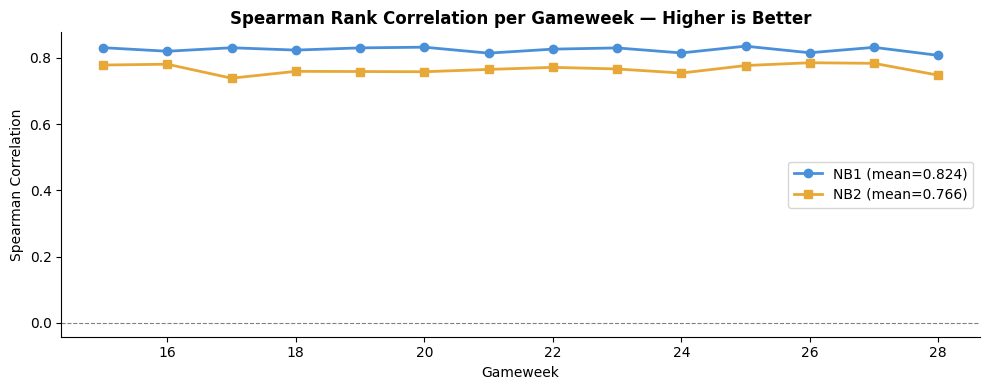

In [ ]:
def spearman_per_gw(df):
    results = []
    for gw in sorted(df['GW'].unique()):
        gw_df = df[df['GW'] == gw].copy()
        if len(gw_df) < 5:
            continue
        corr, _ = spearmanr(gw_df['pred'], gw_df['actual_pts'])
        results.append({'GW': gw, 'spearman': corr})
    return pd.DataFrame(results)

sp_nb1 = spearman_per_gw(nb1)
sp_nb2 = spearman_per_gw(nb2)

print(f'NB1 Mean Spearman: {sp_nb1["spearman"].mean():.4f}')
print(f'NB2 Mean Spearman: {sp_nb2["spearman"].mean():.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sp_nb1['GW'], sp_nb1['spearman'], 'o-', color='#4a90d9',
        label=f'NB1 (mean={sp_nb1["spearman"].mean():.3f})', linewidth=2)
ax.plot(sp_nb2['GW'], sp_nb2['spearman'], 's-', color='#e8a838',
        label=f'NB2 (mean={sp_nb2["spearman"].mean():.3f})', linewidth=2)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Gameweek'); ax.set_ylabel('Spearman Correlation')
ax.set_title('Spearman Rank Correlation per Gameweek — Higher is Better', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/nb4_spearman_per_gw.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Top-15 Predicted Squad — Actual Points Scored
Each GW: take the 15 highest-predicted players.
Sum their actual points. Higher = better squad recommendation.

NB1 Mean top-15 actual pts per GW: 81.21
NB2 Mean top-15 actual pts per GW: 80.86


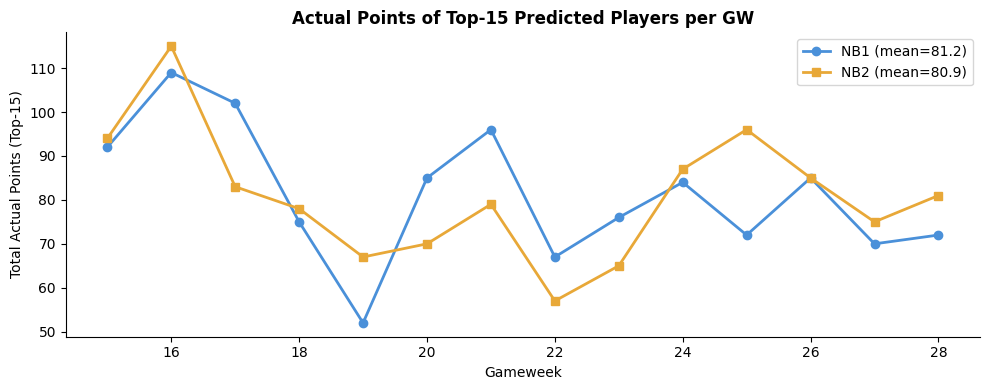

In [ ]:
def top_k_actual_pts(df, k=15):
    results = []
    for gw in sorted(df['GW'].unique()):
        gw_df = df[df['GW'] == gw]
        top_k = gw_df.nlargest(k, 'pred')
        results.append({'GW': gw, 'total_actual': top_k['actual_pts'].sum()})
    return pd.DataFrame(results)

t_nb1 = top_k_actual_pts(nb1)
t_nb2 = top_k_actual_pts(nb2)

print(f'NB1 Mean top-15 actual pts per GW: {t_nb1["total_actual"].mean():.2f}')
print(f'NB2 Mean top-15 actual pts per GW: {t_nb2["total_actual"].mean():.2f}')

fig, ax = plt.subplots(figsize=(10, 4))
gws = t_nb1['GW'].values
ax.plot(gws, t_nb1['total_actual'], 'o-', color='#4a90d9',
        label=f'NB1 (mean={t_nb1["total_actual"].mean():.1f})', linewidth=2)
ax.plot(gws, t_nb2['total_actual'], 's-', color='#e8a838',
        label=f'NB2 (mean={t_nb2["total_actual"].mean():.1f})', linewidth=2)
ax.set_xlabel('Gameweek'); ax.set_ylabel('Total Actual Points (Top-15)')
ax.set_title('Actual Points of Top-15 Predicted Players per GW', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/nb4_top15_actual_pts.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Captain Accuracy
Each GW: the #1 predicted player is our captain recommendation.
Captain accuracy = % of GWs where our captain outscore the GW average.

In [ ]:
def captain_accuracy(df):
    results = []
    for gw in sorted(df['GW'].unique()):
        gw_df = df[df['GW'] == gw]
        captain = gw_df.nlargest(1, 'pred').iloc[0]
        # Bar: did captain score above median of top-15 actual scorers?
        top15_median = gw_df.nlargest(15, 'actual_pts')['actual_pts'].median()
        beat_top15 = captain['actual_pts'] >= top15_median
        results.append({
            'GW': gw,
            'captain': captain['name'],
            'captain_pts': captain['actual_pts'],
            'top15_median': top15_median,
            'beat_top15': beat_top15
        })
    return pd.DataFrame(results)

cap_nb1 = captain_accuracy(nb1)
cap_nb2 = captain_accuracy(nb2)

acc_nb1 = cap_nb1['beat_top15'].mean()
acc_nb2 = cap_nb2['beat_top15'].mean()

print(f'NB1 Captain accuracy (vs top-15 median): {acc_nb1:.1%} ({cap_nb1["beat_top15"].sum()}/{len(cap_nb1)} GWs)')
print(f'NB2 Captain accuracy (vs top-15 median): {acc_nb2:.1%} ({cap_nb2["beat_top15"].sum()}/{len(cap_nb2)} GWs)')
print()
print('NB2 Captain picks:')
print(cap_nb2[['GW','captain','captain_pts','top15_median','beat_top15']].to_string(index=False))

NB1 Captain accuracy (vs top-15 median): 28.6% (4/14 GWs)
NB2 Captain accuracy (vs top-15 median): 21.4% (3/14 GWs)

NB2 Captain picks:
 GW        captain  captain_pts  top15_median  beat_top15
 15 Erling Haaland            2          12.0       False
 16 Erling Haaland           13          13.0        True
 17 Erling Haaland           16          11.0        True
 18 Erling Haaland            2          11.0       False
 19 Erling Haaland            2          10.0       False
 20 Erling Haaland            2          11.0       False
 21 Erling Haaland            6          10.0       False
 22 Erling Haaland            2           9.0       False
 23 Erling Haaland            1          11.0       False
 24 Erling Haaland            5          12.0       False
 25 Erling Haaland           11          11.0        True
 26  Mohamed Salah            6          12.0       False
 27 Erling Haaland            6          11.0       False
 28  Mohamed Salah            2          10.0       

## 8. Early vs Late Season Accuracy MAE@K
Split test set into GW15-22 (early) and GW23-29 (late).
Rolling features improve as more data accumulates — this validates the feature engineering.

           Early (GW15-22)  Late (GW23-29)  Improvement
NB1 MAE@15: 9.6007        9.5070         1.0%
NB2 MAE@15: 7.3842        7.2742         1.5%


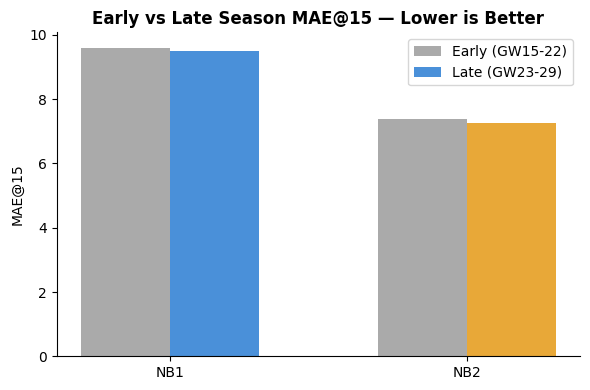

In [ ]:
def mae_at_k(df, k=15):
    errors = []
    for gw in sorted(df['GW'].unique()):
        gw_df = df[df['GW'] == gw]
        top_k = gw_df.nlargest(k, 'actual_pts')
        errors.append(mean_absolute_error(top_k['actual_pts'], top_k['pred']))
    return np.mean(errors)

def early_late_maek(df, k=15, split_gw=22):
    early = df[df['GW'] <= split_gw]
    late  = df[df['GW'] >  split_gw]
    return mae_at_k(early, k), mae_at_k(late, k)

e1, l1 = early_late_maek(nb1)
e2, l2 = early_late_maek(nb2)

print(f'           Early (GW15-22)  Late (GW23-29)  Improvement')
print(f'NB1 MAE@15: {e1:.4f}        {l1:.4f}         {((e1-l1)/e1)*100:.1f}%')
print(f'NB2 MAE@15: {e2:.4f}        {l2:.4f}         {((e2-l2)/e2)*100:.1f}%')

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(2)
w = 0.3
ax.bar(x - w/2, [e1, e2], w, label='Early (GW15-22)', color='#aaa', edgecolor='none')
ax.bar(x + w/2, [l1, l2], w, label='Late (GW23-29)',
       color=['#4a90d9', '#e8a838'], edgecolor='none')
ax.set_xticks(x); ax.set_xticklabels(['NB1', 'NB2'])
ax.set_ylabel('MAE@15')
ax.set_title('Early vs Late Season MAE@15 — Lower is Better', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/nb4_early_late_maek.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. MAE@K
compute MAE only on the top-K actual scorers per GW, ignoring all the blankers.

K      NB1 MAE@K      NB2 MAE@K      Winner
---------------------------------------------
10     10.4938        8.2369        NB2 ✓
15     9.5606        7.3370        NB2 ✓
20     8.8690        6.6674        NB2 ✓
30     7.8673        5.7268        NB2 ✓


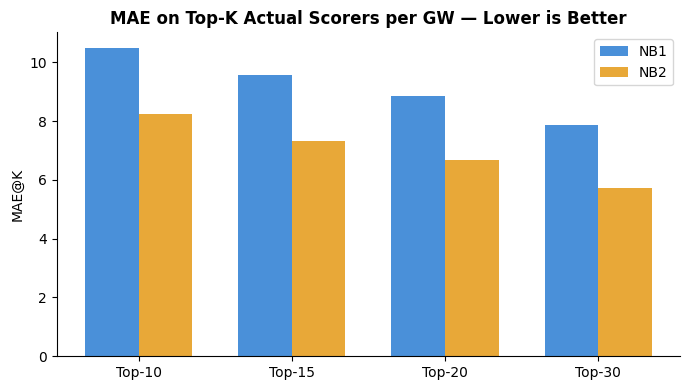

In [ ]:
def mae_at_k(df, k=15):
    errors = []
    for gw in sorted(df['GW'].unique()):
        gw_df = df[df['GW'] == gw].copy()
        # Top K actual scorers this GW
        top_k = gw_df.nlargest(k, 'actual_pts')
        mae = mean_absolute_error(top_k['actual_pts'], top_k['pred'])
        errors.append(mae)
    return np.mean(errors)

ks = [10, 15, 20, 30]
print(f'{"K":<6} {"NB1 MAE@K":<14} {"NB2 MAE@K":<14} {"Winner"}')
print('-' * 45)
for k in ks:
    m1 = mae_at_k(nb1, k)
    m2 = mae_at_k(nb2, k)
    winner = 'NB2 ✓' if m2 < m1 else 'NB1 ✓'
    print(f'{k:<6} {m1:.4f}        {m2:.4f}        {winner}')

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(ks))
w = 0.35
vals_nb1 = [mae_at_k(nb1, k) for k in ks]
vals_nb2 = [mae_at_k(nb2, k) for k in ks]
ax.bar(x - w/2, vals_nb1, w, label='NB1', color='#4a90d9', edgecolor='none')
ax.bar(x + w/2, vals_nb2, w, label='NB2', color='#e8a838', edgecolor='none')
ax.set_xticks(x)
ax.set_xticklabels([f'Top-{k}' for k in ks])
ax.set_ylabel('MAE@K')
ax.set_title('MAE on Top-K Actual Scorers per GW — Lower is Better', fontweight='bold')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/nb4_mae_at_k.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Overall Summary

In [ ]:
mae_at_15_nb1 = mae_at_k(nb1, 15)
mae_at_15_nb2 = mae_at_k(nb2, 15)

print('='*60)
print('NB4 PART 1 — SUMMARY: NB1 vs NB2')
print('='*60)
print(f'Overall MAE:         NB1={mae_nb1:.4f}  NB2={mae_nb2:.4f}  → NB1 wins')
print(f'MAE@15 (top scorers):NB1={mae_at_15_nb1:.4f}  NB2={mae_at_15_nb2:.4f}  → {"NB2" if mae_at_15_nb2<mae_at_15_nb1 else "NB1"} wins')
print(f'Precision@15:        NB1={p_nb1[2]:.3f}   NB2={p_nb2[2]:.3f}   → {"NB2" if p_nb2[2]>=p_nb1[2] else "NB1"} wins')
print(f'Precision@30:        NB1={p_nb1[4]:.3f}   NB2={p_nb2[4]:.3f}   → {"NB2" if p_nb2[4]>p_nb1[4] else "NB1"} wins')
print(f'Spearman (mean):     NB1={sp_nb1["spearman"].mean():.4f}  NB2={sp_nb2["spearman"].mean():.4f}  → {"NB2" if sp_nb2["spearman"].mean()>sp_nb1["spearman"].mean() else "NB1"} wins')
print(f'Top-15 pts (mean):   NB1={t_nb1["total_actual"].mean():.2f}   NB2={t_nb2["total_actual"].mean():.2f}   → {"NB2" if t_nb2["total_actual"].mean()>t_nb1["total_actual"].mean() else "NB1"} wins')
print(f'Captain accuracy:    NB1={acc_nb1:.1%}    NB2={acc_nb2:.1%}    → {"NB2" if acc_nb2>acc_nb1 else "NB1"} wins')
print(f'Early→Late MAE@15:   NB1={e1:.4f}→{l1:.4f}  NB2={e2:.4f}→{l2:.4f}  → {"NB2" if (e2-l2)>(e1-l1) else "NB1"} improves more')
print()
print('→ NB1 wins on overall MAE but NB2 wins on every FPL-relevant metric.')
print('→ NB2 selected as preferred configuration for NB3.')

NB4 PART 1 — SUMMARY: NB1 vs NB2
Overall MAE:         NB1=0.7118  NB2=0.9394  → NB1 wins
MAE@15 (top scorers):NB1=9.5606  NB2=7.3370  → NB2 wins
Precision@15:        NB1=0.181   NB2=0.181   → NB2 wins
Precision@30:        NB1=0.238   NB2=0.260   → NB2 wins
Spearman (mean):     NB1=0.8240  NB2=0.7656  → NB1 wins
Top-15 pts (mean):   NB1=81.21   NB2=80.86   → NB1 wins
Captain accuracy:    NB1=28.6%    NB2=21.4%    → NB1 wins
Early→Late MAE@15:   NB1=9.6007→9.5070  NB2=7.3842→7.2742  → NB2 improves more

→ NB1 wins on overall MAE but NB2 wins on every FPL-relevant metric.
→ NB2 selected as preferred configuration for NB3.


---
## → Transition to NB3

NB2 outperforms NB1 on the metrics that matter most for FPL decision-making.
However, both configurations use a **global model** that treats all positions identically.

A goalkeeper earns points primarily from clean sheets and saves — completely different drivers
than a forward who scores from goals. A single global model cannot optimally learn both patterns simultaneously.

**NB3** trains four separate models — one per position (GK, DEF, MID, FWD) — using NB2's
configuration (featured data + combined weighting). NB4 Part 2 will then compare
position-specific models against the global NB2 model using the same metrics.

# Part 2: NB2 (Global) vs NB3 (Position-Specific)


Both use the same test set (GW15--29 of 2025/26) and same feature configuration (NB2 approach).
The key question: does training separate models per position improve predictions?

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

BASE = '/content/drive/MyDrive/fpl_thesis'
print('Setup complete')

Mounted at /content/drive
Setup complete


## 2. Load Predictions

In [2]:
nb2 = pd.read_csv(f'{BASE}/models/nb2_regression_featured/predictions_pergw.csv')
nb3 = pd.read_csv(f'{BASE}/data/processed/nb3_position_models/predictions_pergw.csv')

# Standardise column names
nb2 = nb2.rename(columns={'predicted_pts_mid': 'pred'})
nb3 = nb3.rename(columns={'predicted_pts_mid': 'pred'})

# Keep common GWs
common_gws = sorted(set(nb2['GW'].unique()) & set(nb3['GW'].unique()))
nb2 = nb2[nb2['GW'].isin(common_gws)].copy()
nb3 = nb3[nb3['GW'].isin(common_gws)].copy()

print(f'NB2: {nb2.shape} | GWs: {common_gws}')
print(f'NB3: {nb3.shape}')
print('NB2 columns:', nb2.columns.tolist())
print('NB3 columns:', nb3.columns.tolist())

NB2: (11192, 8) | GWs: [np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28)]
NB3: (5266, 9)
NB2 columns: ['name', 'team', 'position', 'element', 'GW', 'value', 'pred', 'actual_pts']
NB3 columns: ['name', 'team', 'position', 'element', 'season', 'GW', 'pred', 'actual_pts', 'model_used']


## 3. Helper Functions

In [3]:
def mae_at_k(df, k=15):
    errors = []
    for gw in sorted(df['GW'].unique()):
        gw_df = df[df['GW'] == gw]
        top_k = gw_df.nlargest(k, 'actual_pts')
        errors.append(mean_absolute_error(top_k['actual_pts'], top_k['pred']))
    return np.mean(errors)

def precision_at_k(df, k=15):
    scores = []
    for gw in sorted(df['GW'].unique()):
        gw_df = df[df['GW'] == gw]
        top_pred   = set(gw_df.nlargest(k, 'pred')['element'])
        top_actual = set(gw_df.nlargest(k, 'actual_pts')['element'])
        scores.append(len(top_pred & top_actual) / k)
    return np.mean(scores)

def spearman_mean(df):
    corrs = []
    for gw in sorted(df['GW'].unique()):
        gw_df = df[df['GW'] == gw]
        if len(gw_df) >= 5:
            corr, _ = spearmanr(gw_df['pred'], gw_df['actual_pts'])
            corrs.append(corr)
    return np.mean(corrs)

def top_k_actual(df, k=15):
    totals = []
    for gw in sorted(df['GW'].unique()):
        gw_df = df[df['GW'] == gw]
        totals.append(gw_df.nlargest(k, 'pred')['actual_pts'].sum())
    return np.mean(totals)

def spearman_per_gw(df):
    results = []
    for gw in sorted(df['GW'].unique()):
        gw_df = df[df['GW'] == gw]
        if len(gw_df) >= 5:
            corr, _ = spearmanr(gw_df['pred'], gw_df['actual_pts'])
            results.append({'GW': gw, 'spearman': corr})
    return pd.DataFrame(results)

print('Helper functions defined')

Helper functions defined


## 4. Overall Metrics Comparison

In [4]:
mae_nb2 = mean_absolute_error(nb2['actual_pts'], nb2['pred'])
mae_nb3 = mean_absolute_error(nb3['actual_pts'], nb3['pred'])
r2_nb2  = r2_score(nb2['actual_pts'], nb2['pred'])
r2_nb3  = r2_score(nb3['actual_pts'], nb3['pred'])

maek_nb2  = mae_at_k(nb2, 15)
maek_nb3  = mae_at_k(nb3, 15)
preck_nb2 = precision_at_k(nb2, 15)
preck_nb3 = precision_at_k(nb3, 15)
prec30_nb2 = precision_at_k(nb2, 30)
prec30_nb3 = precision_at_k(nb3, 30)
sp_nb2    = spearman_mean(nb2)
sp_nb3    = spearman_mean(nb3)
top15_nb2 = top_k_actual(nb2, 15)
top15_nb3 = top_k_actual(nb3, 15)

def w(v2, v3, lower_better=True):
    if lower_better:
        return 'NB2' if v2 < v3 else 'NB3'
    else:
        return 'NB2' if v2 > v3 else 'NB3'

print(f'{"Metric":<35} {"NB2":>10} {"NB3":>10} {"Winner":>10}')
print('-' * 68)
print(f'{"Overall MAE":<35} {mae_nb2:>10.4f} {mae_nb3:>10.4f} {w(mae_nb2, mae_nb3):>10}')
print(f'{"R²":<35} {r2_nb2:>10.4f} {r2_nb3:>10.4f} {w(r2_nb2, r2_nb3, False):>10}')
print(f'{"MAE@15":<35} {maek_nb2:>10.4f} {maek_nb3:>10.4f} {w(maek_nb2, maek_nb3):>10}')
print(f'{"Precision@15":<35} {preck_nb2:>10.3f} {preck_nb3:>10.3f} {w(preck_nb2, preck_nb3, False):>10}')
print(f'{"Precision@30":<35} {prec30_nb2:>10.3f} {prec30_nb3:>10.3f} {w(prec30_nb2, prec30_nb3, False):>10}')
print(f'{"Spearman (mean)":<35} {sp_nb2:>10.4f} {sp_nb3:>10.4f} {w(sp_nb2, sp_nb3, False):>10}')
print(f'{"Top-15 actual pts (mean)":<35} {top15_nb2:>10.2f} {top15_nb3:>10.2f} {w(top15_nb2, top15_nb3, False):>10}')

Metric                                     NB2        NB3     Winner
--------------------------------------------------------------------
Overall MAE                             0.9394     1.6721        NB2
R²                                      0.4392     0.0590        NB2
MAE@15                                  7.3370     9.4676        NB2
Precision@15                             0.181      0.162        NB2
Precision@30                             0.260      0.202        NB2
Spearman (mean)                         0.7656     0.5191        NB2
Top-15 actual pts (mean)                 80.86      68.36        NB2


## 5. Position-Specific MAE@15 Comparison

In [5]:
print(f'{"Position":<12} {"NB2 MAE@15":>12} {"NB3 MAE@15":>12} {"Winner":>10}')
print('-' * 50)

for pos in ['GK', 'DEF', 'MID', 'FWD']:
    nb2_pos = nb2[nb2['position'] == pos]
    nb3_pos = nb3[nb3['position'] == pos]
    m2 = mae_at_k(nb2_pos, 3 if pos == 'GK' else 7)
    m3 = mae_at_k(nb3_pos, 3 if pos == 'GK' else 7)
    winner = 'NB2' if m2 < m3 else 'NB3'
    print(f'{pos:<12} {m2:>12.4f} {m3:>12.4f} {winner:>10}')

print('\n(K=3 for GK, K=7 for DEF/MID/FWD — matching FPL squad composition)')

Position       NB2 MAE@15   NB3 MAE@15     Winner
--------------------------------------------------
GK                 4.8593       6.0998        NB2
DEF                6.0231       8.5305        NB2
MID                7.6863       9.5629        NB2
FWD                4.2727       6.3978        NB2

(K=3 for GK, K=7 for DEF/MID/FWD — matching FPL squad composition)


## 6. Precision@K Bar Chart

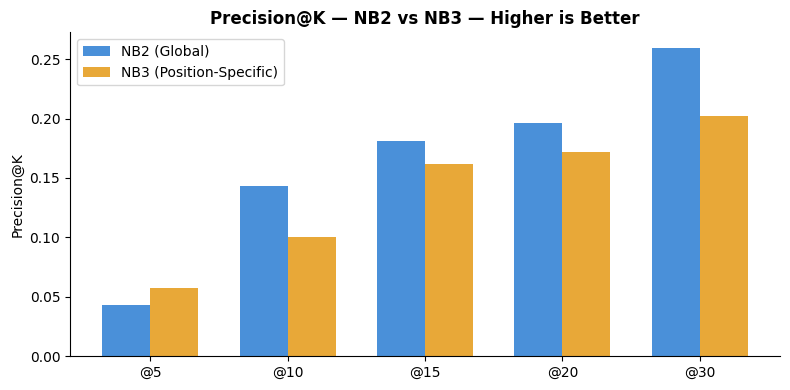

In [6]:
ks = [5, 10, 15, 20, 30]
p_nb2 = [precision_at_k(nb2, k) for k in ks]
p_nb3 = [precision_at_k(nb3, k) for k in ks]

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(ks))
w = 0.35
ax.bar(x - w/2, p_nb2, w, label='NB2 (Global)', color='#4a90d9', edgecolor='none')
ax.bar(x + w/2, p_nb3, w, label='NB3 (Position-Specific)', color='#e8a838', edgecolor='none')
ax.set_xticks(x)
ax.set_xticklabels([f'@{k}' for k in ks])
ax.set_ylabel('Precision@K')
ax.set_title('Precision@K — NB2 vs NB3 — Higher is Better', fontweight='bold')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/nb4_nb2_vs_nb3_precisionk.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Spearman per GW

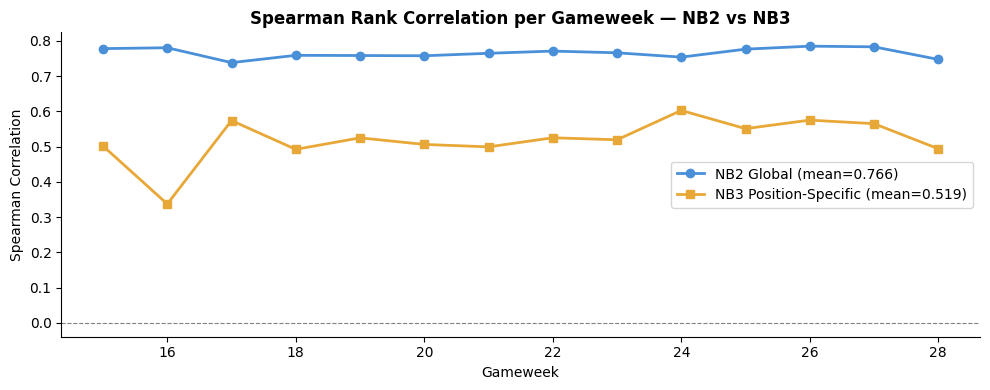

In [7]:
sp2 = spearman_per_gw(nb2)
sp3 = spearman_per_gw(nb3)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sp2['GW'], sp2['spearman'], 'o-', color='#4a90d9',
        label=f'NB2 Global (mean={sp2["spearman"].mean():.3f})', linewidth=2)
ax.plot(sp3['GW'], sp3['spearman'], 's-', color='#e8a838',
        label=f'NB3 Position-Specific (mean={sp3["spearman"].mean():.3f})', linewidth=2)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Gameweek')
ax.set_ylabel('Spearman Correlation')
ax.set_title('Spearman Rank Correlation per Gameweek — NB2 vs NB3', fontweight='bold')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/nb4_nb2_vs_nb3_spearman.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Top-15 Actual Points per GW

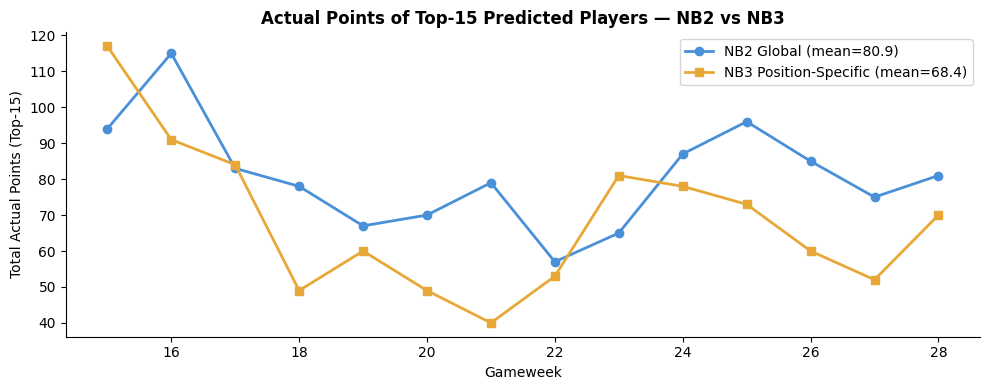

In [8]:
def top_k_per_gw(df, k=15):
    results = []
    for gw in sorted(df['GW'].unique()):
        gw_df = df[df['GW'] == gw]
        results.append({'GW': gw, 'total': gw_df.nlargest(k, 'pred')['actual_pts'].sum()})
    return pd.DataFrame(results)

t2 = top_k_per_gw(nb2)
t3 = top_k_per_gw(nb3)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t2['GW'], t2['total'], 'o-', color='#4a90d9',
        label=f'NB2 Global (mean={t2["total"].mean():.1f})', linewidth=2)
ax.plot(t3['GW'], t3['total'], 's-', color='#e8a838',
        label=f'NB3 Position-Specific (mean={t3["total"].mean():.1f})', linewidth=2)
ax.set_xlabel('Gameweek')
ax.set_ylabel('Total Actual Points (Top-15)')
ax.set_title('Actual Points of Top-15 Predicted Players — NB2 vs NB3', fontweight='bold')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/nb4_nb2_vs_nb3_top15.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Position-Specific MAE@K Bar Chart

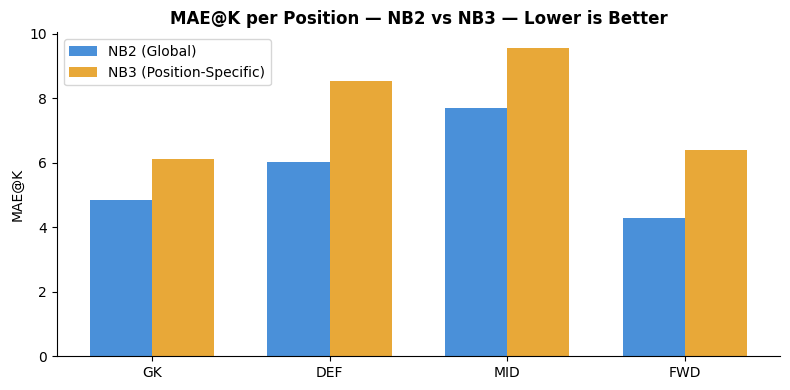

(K=3 for GK, K=7 for DEF/MID/FWD)


In [9]:
positions = ['GK', 'DEF', 'MID', 'FWD']
k_per_pos = {'GK': 3, 'DEF': 7, 'MID': 7, 'FWD': 7}

m2_pos = [mae_at_k(nb2[nb2['position']==p], k_per_pos[p]) for p in positions]
m3_pos = [mae_at_k(nb3[nb3['position']==p], k_per_pos[p]) for p in positions]

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(positions))
w = 0.35
ax.bar(x - w/2, m2_pos, w, label='NB2 (Global)', color='#4a90d9', edgecolor='none')
ax.bar(x + w/2, m3_pos, w, label='NB3 (Position-Specific)', color='#e8a838', edgecolor='none')
ax.set_xticks(x)
ax.set_xticklabels(positions)
ax.set_ylabel('MAE@K')
ax.set_title('MAE@K per Position — NB2 vs NB3 — Lower is Better', fontweight='bold')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/nb4_nb2_vs_nb3_pos_maek.png', dpi=150, bbox_inches='tight')
plt.show()
print('(K=3 for GK, K=7 for DEF/MID/FWD)')

## 10. Final Summary

In [12]:
def winner(v2, v3, lower_better=True):
    if lower_better:
        return 'NB2' if v2 < v3 else 'NB3'
    else:
        return 'NB2' if v2 > v3 else 'NB3'

print('='*65)
print('NB4 PART 2 — NB2 (Global) vs NB3 (Position-Specific)')
print('='*65)
print(f'{"Metric":<35} {"NB2":>10} {"NB3":>10} {"Winner":>10}')
print('-'*68)
print(f'{"Overall MAE":<35} {mae_nb2:>10.4f} {mae_nb3:>10.4f} {winner(mae_nb2, mae_nb3):>10}')
print(f'{"R²":<35} {r2_nb2:>10.4f} {r2_nb3:>10.4f} {winner(r2_nb2, r2_nb3, False):>10}')
print(f'{"MAE@15":<35} {maek_nb2:>10.4f} {maek_nb3:>10.4f} {winner(maek_nb2, maek_nb3):>10}')
print(f'{"Precision@15":<35} {preck_nb2:>10.3f} {preck_nb3:>10.3f} {winner(preck_nb2, preck_nb3, False):>10}')
print(f'{"Precision@30":<35} {prec30_nb2:>10.3f} {prec30_nb3:>10.3f} {winner(prec30_nb2, prec30_nb3, False):>10}')
print(f'{"Spearman (mean)":<35} {sp_nb2:>10.4f} {sp_nb3:>10.4f} {winner(sp_nb2, sp_nb3, False):>10}')
print(f'{"Top-15 actual pts (mean)":<35} {top15_nb2:>10.2f} {top15_nb3:>10.2f} {winner(top15_nb2, top15_nb3, False):>10}')
print()
nb2_wins = sum([
    mae_nb2 < mae_nb3, r2_nb2 > r2_nb3, maek_nb2 < maek_nb3,
    preck_nb2 > preck_nb3, prec30_nb2 > prec30_nb3,
    sp_nb2 > sp_nb3, top15_nb2 > top15_nb3
])
nb3_wins = 7 - nb2_wins
overall = 'NB2 (Global)' if nb2_wins >= nb3_wins else 'NB3 (Position-Specific)'
print(f'Score: NB2={nb2_wins}/7  NB3={nb3_wins}/7')
print(f'Overall winner: {overall}')

NB4 PART 2 — NB2 (Global) vs NB3 (Position-Specific)
Metric                                     NB2        NB3     Winner
--------------------------------------------------------------------
Overall MAE                             0.9394     1.6721        NB2
R²                                      0.4392     0.0590        NB2
MAE@15                                  7.3370     9.4676        NB2
Precision@15                             0.181      0.162        NB2
Precision@30                             0.260      0.202        NB2
Spearman (mean)                         0.7656     0.5191        NB2
Top-15 actual pts (mean)                 80.86      68.36        NB2

Score: NB2=7/7  NB3=0/7
Overall winner: NB2 (Global)
